In [1]:
import pandas as pd
import numpy as np

sales = pd.read_csv("../data/processed/sales.csv")
web_traffic = pd.read_csv("../data/processed/web_traffic.csv")
products = pd.read_csv("../data/processed/products.csv")
orders = pd.read_csv("../data/processed/orders.csv")
promotions = pd.read_csv("../data/processed/promotions.csv")

np.random.seed(0)

In [2]:
def percent_missing(file_name):
    total = np.prod(file_name.shape)
    missing = file_name.isnull().sum()
    total_missing = missing.sum()
    per_missing = (total_missing/total) * 100
    return per_missing

In [3]:
print(f"Percent Missing sales: {percent_missing(sales)}")
print(f"Percent Missing web_traffic: {percent_missing(web_traffic)}")
print(f"Percent Missing products: {percent_missing(products)}")
print(f"Percent Missing orders: {percent_missing(orders)}")
print(f"Percent Missing promotions: {percent_missing(promotions)}")


Percent Missing sales: 0.0
Percent Missing web_traffic: 0.0
Percent Missing products: 0.0
Percent Missing orders: 0.0
Percent Missing promotions: 8.0


In [4]:
promotions.head()

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


In [5]:
promotions['applicable_category'] = promotions['applicable_category'].fillna('All')

In [6]:
promotions.head()

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,All,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,All,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,All,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,All,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


In [7]:
print(f"Percent Missing promotions: {percent_missing(promotions)}")

Percent Missing promotions: 0.0


In [8]:
print(f"Date type sales: {sales['Date'].dtype}")
print(f"Date type web_traffic: {web_traffic['date'].dtype}")
print(f"Date type orders: {orders['order_date'].dtype}")
print(f"Date type promotions: {promotions['start_date'].dtype}, {promotions['end_date'].dtype}")

Date type sales: object
Date type web_traffic: object
Date type orders: object
Date type promotions: object, object


In [9]:
sales['Date'] = pd.to_datetime(sales['Date'], format="%Y-%m-%d")
web_traffic['date'] = pd.to_datetime(web_traffic['date'], format="%Y-%m-%d")
orders['order_date'] = pd.to_datetime(orders['order_date'], format="%Y-%m-%d")
promotions['start_date'] = pd.to_datetime(promotions['start_date'], format="%Y-%m-%d")
promotions['end_date'] = pd.to_datetime(promotions['end_date'], format="%Y-%m-%d")

In [10]:
print(f"Date type sales: {sales['Date'].dtype}")
print(f"Date type web_traffic: {web_traffic['date'].dtype}")
print(f"Date type orders: {orders['order_date'].dtype}")
print(f"Date type promotions: {promotions['start_date'].dtype}, {promotions['end_date'].dtype}")

Date type sales: datetime64[ns]
Date type web_traffic: datetime64[ns]
Date type orders: datetime64[ns]
Date type promotions: datetime64[ns], datetime64[ns]


In [11]:
dfs = {
    "Sales": sales,
    "Web Traffic": web_traffic,
    "Products": products,
    "Orders": orders,
    "Promotions": promotions
}

def check_quality(name, df):
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates} dòng trùng lặp")

for name, df in dfs.items():
    check_quality(name, df)

Sales: 0 dòng trùng lặp
Web Traffic: 0 dòng trùng lặp
Products: 0 dòng trùng lặp
Orders: 0 dòng trùng lặp
Promotions: 0 dòng trùng lặp


In [12]:
# Kiểm tra Products: Giá vốn < Giá bán 
invalid_products = products[products['cogs'] >= products['price']]
print(f"cogs < price: {len(invalid_products)}")

# Kiểm tra Promotions: Ngày bắt đầu < Ngày kết thúc 
invalid_promos = promotions[promotions['start_date'] >= promotions['end_date']]
print(f"start_date < end_date: {len(invalid_promos)}")

# Kiểm tra Sales: Doanh thu hoặc COGS có bị âm không 
invalid_sales = sales[(sales['Revenue'] < 0) | (sales['COGS'] < 0)]
print(f"Revenue, COGS < 0: {len(invalid_sales)}")

# Kiểm tra Web Traffic: Các tỷ lệ (rate) phải nằm trong khoảng [0, 1] 
invalid_traffic = web_traffic[(web_traffic['bounce_rate'] < 0) | (web_traffic['bounce_rate'] > 1)]
print(f"rate < 0, rate > 1: {len(invalid_traffic)}")

cogs < price: 0
start_date < end_date: 0
Revenue, COGS < 0: 0
rate < 0, rate > 1: 0


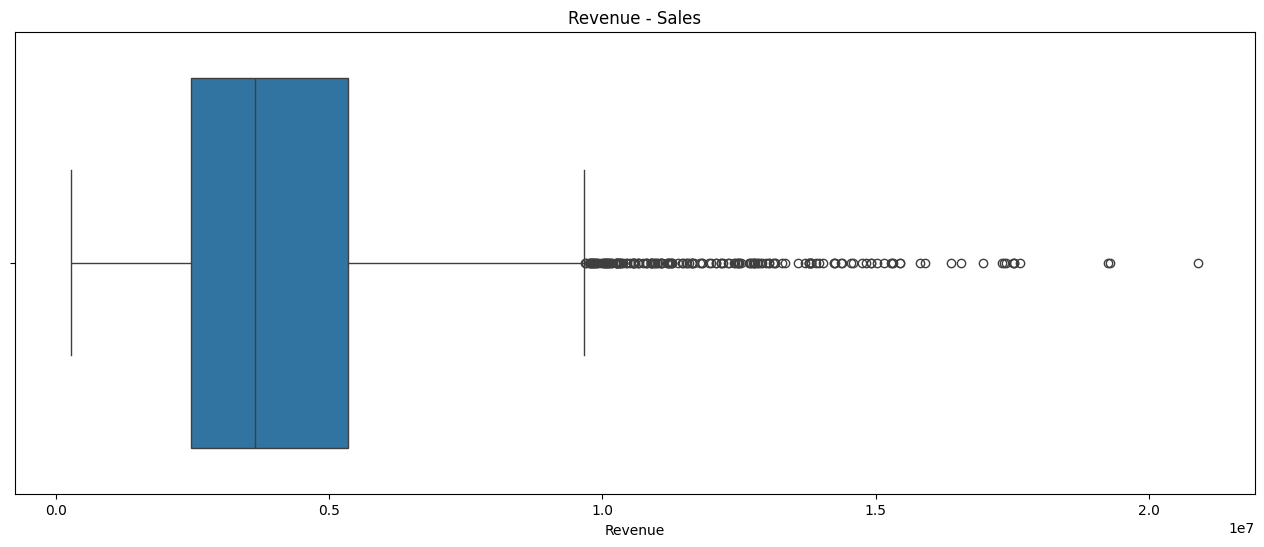

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Revenue trong sales.csv 
plt.figure(figsize=(16,6)) 
sns.boxplot(x=sales['Revenue'])
plt.title("Revenue - Sales")
plt.show()

In [14]:
Q1 = sales['Revenue'].quantile(0.25)
Q3 = sales['Revenue'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

high_revenue_days = sales[sales['Revenue'] > upper_limit]
print(high_revenue_days.sort_values(by='Revenue', ascending=False).head(10))

           Date      Revenue         COGS
2156 2018-05-30  20905271.35  16535857.67
2157 2018-05-31  19289944.12  15561846.10
2158 2018-06-01  19245165.78  15287542.60
1793 2017-06-01  17639270.88  14102311.81
2159 2018-06-02  17529108.34  13707707.44
1794 2017-06-02  17528852.88  14154253.77
1730 2017-03-30  17516038.82  16224964.49
1394 2016-04-28  17388183.19  13978683.94
664  2014-04-29  17347427.27  13752034.86
1792 2017-05-31  17314841.86  13846685.08


In [15]:
def is_promo_day(check_date):
    match = promotions[(promotions['start_date'] <= check_date) & 
                       (promotions['end_date'] >= check_date)]
    return not match.empty

high_revenue_days = high_revenue_days.copy() 
high_revenue_days['is_promo'] = high_revenue_days['Date'].apply(is_promo_day)

print(high_revenue_days[['Date', 'Revenue', 'is_promo']].sort_values(by='Revenue', ascending=False).head(10))

           Date      Revenue  is_promo
2156 2018-05-30  20905271.35     False
2157 2018-05-31  19289944.12     False
2158 2018-06-01  19245165.78     False
1793 2017-06-01  17639270.88     False
2159 2018-06-02  17529108.34     False
1794 2017-06-02  17528852.88     False
1730 2017-03-30  17516038.82      True
1394 2016-04-28  17388183.19     False
664  2014-04-29  17347427.27     False
1792 2017-05-31  17314841.86     False


In [16]:
fixed_holidays = [
    (1, 1),   # Tết Dương lịch
    (4, 30),  # Giải phóng miền Nam
    (5, 1),   # Quốc tế Lao động
    (6, 1),   # Quốc tế Thiếu nhi
    (9, 2),   # Quốc khánh
    (12, 25)  # Giáng sinh
]

def is_near_holiday(check_date):
    for month, day in fixed_holidays:
        holiday_this_year = pd.Timestamp(year=check_date.year, month=month, day=day)
        if (check_date <= holiday_this_year) and \
           (check_date >= holiday_this_year - pd.Timedelta(days=3)):
            return 1
    return 0

sales['is_holiday'] = sales['Date'].apply(is_near_holiday)

In [18]:
sales.to_csv('../data/processed/sales.csv', index=False)

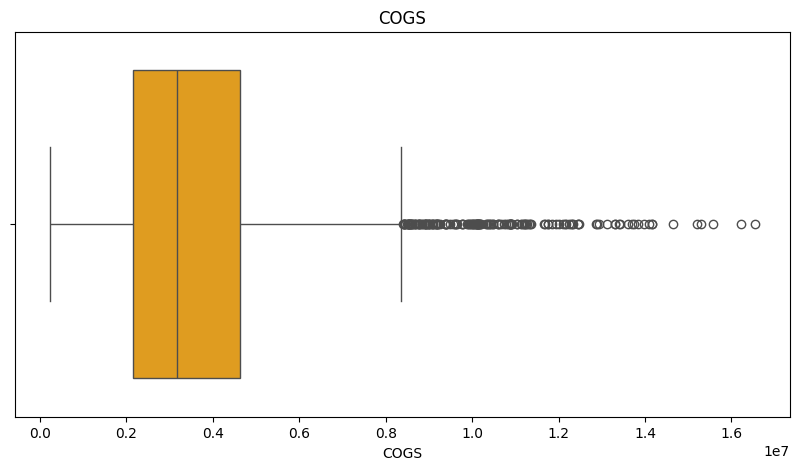

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=sales['COGS'], color='orange')
plt.title("COGS")
plt.show()

In [23]:
Q1_cogs = sales['COGS'].quantile(0.25)
Q3_cogs = sales['COGS'].quantile(0.75)
IQR_cogs = Q3_cogs - Q1_cogs
upper_limit_cogs = Q3_cogs + 1.5 * IQR_cogs
lower_limit_cogs = Q1_cogs - 1.5 * IQR_cogs

cogs_outliers = sales[(sales['COGS'] > upper_limit_cogs) | (sales['COGS'] < lower_limit_cogs)]
print(f"Số lượng Outliers của COGS: {len(cogs_outliers)}")
display(cogs_outliers.sort_values(by='COGS', ascending=False).head(10))

Số lượng Outliers của COGS: 165


,Date,Revenue,COGS,is_holiday
2156,2018-05-30,20905271.35,16535857.67,1
1730,2017-03-30,17516038.82,16224964.49,0
2157,2018-05-31,19289944.12,15561846.10,1
2158,2018-06-01,19245165.78,15287542.60,1
1731,2017-03-31,16556662.03,15209810.10,0
1732,2017-04-01,15808755.61,14645912.76,0
1821,2017-06-29,14575854.67,14163551.21,0
1794,2017-06-02,17528852.88,14154253.77,0
1793,2017-06-01,17639270.88,14102311.81,1
1394,2016-04-28,17388183.19,13978683.94,1


In [24]:
sales['log_Revenue'] = np.log1p(sales['Revenue'])
sales['log_COGS'] = np.log1p(sales['COGS'])